In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
N = 100
S = 7
R = 10000
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)

In [5]:
def simular_sin_intercambio():
    album = set()
    sobres = 0
    while len(album) < N:
        sobre = random.sample(range(N), S)
        for estampa in sobre:
            album.add(estampa)
        sobres += 1
    return sobres

In [14]:
def simular_con_intercambio(K):
    album = set()
    repetidas = 0
    sobres = 0
    while len(album) < N:
        sobre = random.sample(range(N), S)
        for estampa in sobre:
            if estampa in album:
                repetidas += 1
            else:
                album.add(estampa)
        while repetidas >= K and len(album) < N:
            faltantes = list(set(range(N)) - album)
            nueva = random.choice(faltantes)
            album.add(nueva)
            repetidas -= K
        sobres += 1
    return sobres

In [7]:
Ks = [1, 2, 5, 10]

In [8]:
resultados_base = [simular_sin_intercambio() for _ in range(R)]
media_base = np.mean(resultados_base)
std_base = np.std(resultados_base)
print('Sin intercambio')
print('Media:', media_base)
print('Desviacion:', std_base)

Sin intercambio
Media: 72.2408
Desviacion: 17.213193061137726


In [15]:
resultados_K = {}
for K in Ks:
    simulaciones = [simular_con_intercambio(K) for _ in range(R)]
    resultados_K[K] = simulaciones
    media = np.mean(simulaciones)
    std = np.std(simulaciones)
    reduccion = ((media_base - media) / media_base) * 100
    print(f'\nK = {K}')
    print('Media:', round(media, 2))
    print('Desviacion:', round(std, 2))
    print('Reduccion %:', round(reduccion, 2))


K = 1
Media: 15.0
Desviacion: 0.0
Reduccion %: 79.24

K = 2
Media: 19.85
Desviacion: 0.54
Reduccion %: 72.52

K = 5
Media: 28.08
Desviacion: 1.41
Reduccion %: 61.13

K = 10
Media: 35.18
Desviacion: 2.45
Reduccion %: 51.3


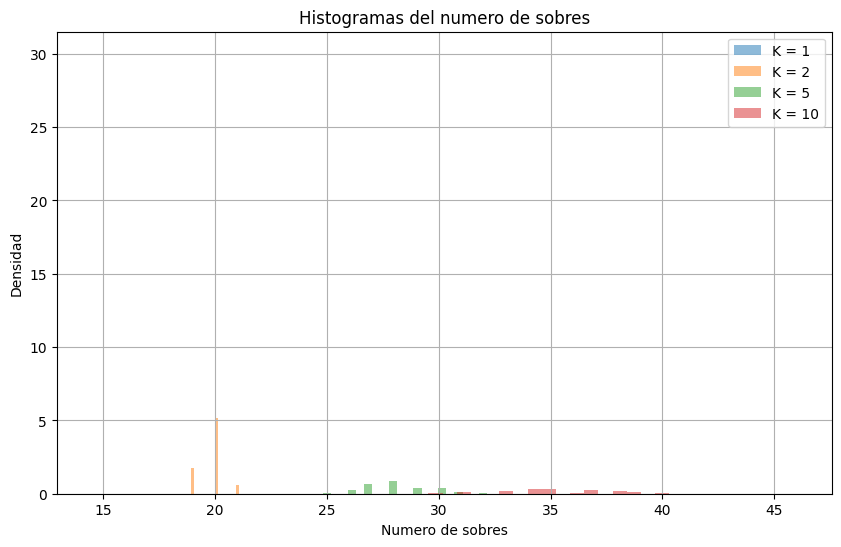

In [16]:
plt.figure(figsize = (10, 6))
for K in Ks:
    plt.hist(resultados_K[K],
             bins = 30,
             alpha = 0.5,
             density = True,
             label = f'K = {K}')
plt.xlabel('Numero de sobres')
plt.ylabel('Densidad')
plt.title('Histogramas del numero de sobres')
plt.legend()
plt.grid()
plt.show()

In [17]:
def completar_album_M_sobres(M, K = None):
    album = set()
    repetidas = 0
    for _ in range(M):
        sobre = random.sample(range(N), S)
        for estampa in sobre:
            if estampa in album:
                if K is not None:
                    repetidas += 1
            else:
                album.add(estampa)
        if K is not None:
            while repetidas >= K and len(album) < N:
                faltantes = list(set(range(N)) - album)
                nueva = random.choice(faltantes)
                album.add(nueva)
                repetidas -= K
    return len(album) == N

In [18]:
Ms = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

In [19]:
probabilidades = {}
probs_base = []
for M in Ms:
    exitos = sum(completar_album_M_sobres(M) for _ in range(R))
    probs_base.append(exitos / R)
probabilidades['Sin intercambio'] = probs_base

In [20]:
for K in Ks:
    probs = []
    for M in Ms:
        exitos = sum(completar_album_M_sobres(M, K) for _ in range(R))
        probs.append(exitos / R)
    probabilidades[K] = probs

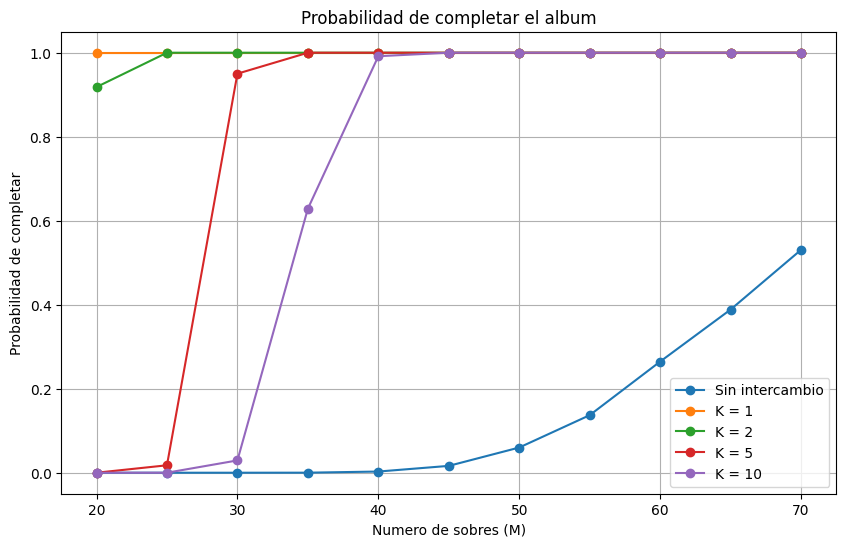

In [21]:
plt.figure(figsize = (10, 6))
plt.plot(Ms,
         probabilidades['Sin intercambio'],
         marker = 'o',
         label = 'Sin intercambio')
for K in Ks:
    plt.plot(Ms,
             probabilidades[K],
             marker = 'o',
             label = f'K = {K}')
plt.xlabel('Numero de sobres (M)')
plt.ylabel('Probabilidad de completar')
plt.title('Probabilidad de completar el album')
plt.grid()
plt.legend()
plt.show()

In [26]:
niveles = [0.5, 0.75, 0.9]
for K in Ks:
    print(f"\nK = {K}")
    probs = probabilidades[K]
    for nivel in niveles:
        encontrado = None
        for M, p in zip(Ms, probs):
            if p >= nivel:
                encontrado = M
                break
        print(f"Probabilidad {nivel*100:.0f}% -> M = {encontrado}")


K = 1
Probabilidad 50% -> M = 20
Probabilidad 75% -> M = 20
Probabilidad 90% -> M = 20

K = 2
Probabilidad 50% -> M = 20
Probabilidad 75% -> M = 20
Probabilidad 90% -> M = 20

K = 5
Probabilidad 50% -> M = 30
Probabilidad 75% -> M = 30
Probabilidad 90% -> M = 30

K = 10
Probabilidad 50% -> M = 35
Probabilidad 75% -> M = 40
Probabilidad 90% -> M = 40


Pregunta 1

Como afecta disminuir K? Mientras mas pequeño es K es mas facil intercambiar repetidas, se obtienen estampas nuevas mas rapido, disminuye el numero esperado de sobres, aumenta la probabilidad de completar el album. La relacion no es lineal. Como por ejemplo: pasar de K=10 a K=5 produce una mejora importante, pero pasar de K=2 a K=1 ya no mejora tanto. Esto ocurre porque el beneficio marginal disminuye.

Pregunta 2

In [27]:
ahorro_sobres = media_base - np.mean(resultados_K[2])
ahorro_quetzales = ahorro_sobres * 9.50
print('Ahorro promedio de sobres:', ahorro_sobres)
print('Ahorro en quetzales: Q', ahorro_quetzales)

Ahorro promedio de sobres: 52.3899
Ahorro en quetzales: Q 497.70405


Con K=2 se necesitan menos sobres en promedio, lo que representa un ahorro economico significativo

Pregunta 3

In [29]:
indice = Ms.index(45)
p10 = probabilidades[10][indice]
p5 = probabilidades[5][indice]
p1 = probabilidades[1][indice]
print('K10 -> K5:', p5 - p10)
print('K5 -> K1:', p1 - p5)

K10 -> K5: 0.0
K5 -> K1: 0.0


Pregunta 4

Existe un K donde mejorar ya casi no ayuda? Si generalmente cuando K <= 2, las mejoras adicionales son pequeñas. La razon es porque ya casi todas las repetidas se convierten rapidamente en nuevas estampas, entonces el proceso se vuelve cercano al caso ideal.

Pregunta 5

Cada sobre cuesta 9.50 y cada sobre trae 7 estampas, el costo por estampa es de 9.50/7 = Q1.36 por estampa. Entonces conseguir K repetidas costo aproximadamente K=1 -> Q1.36  K=2 -> Q2.71  K=5 -> Q6.79  K=10 -> Q13.57
En conclusion menor K es igual a mejor rentabilidad, K=1 seria el sistema mas favorable